Task 1

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2806s 16us/step
Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing labels shape: (10000, 1)


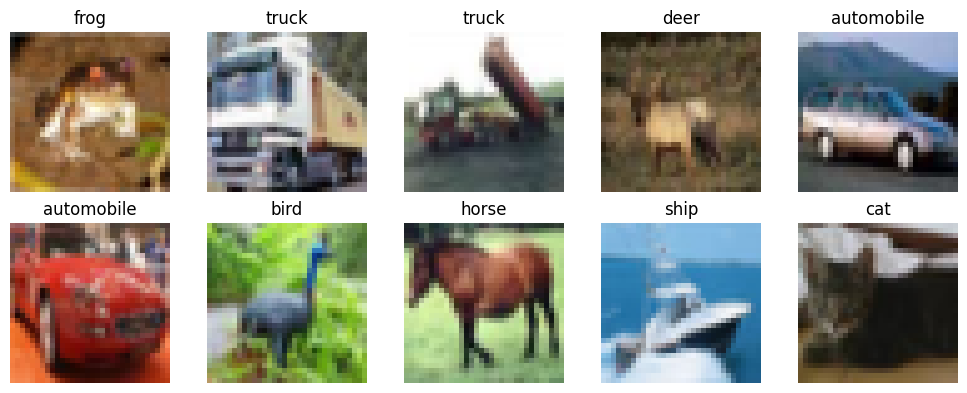

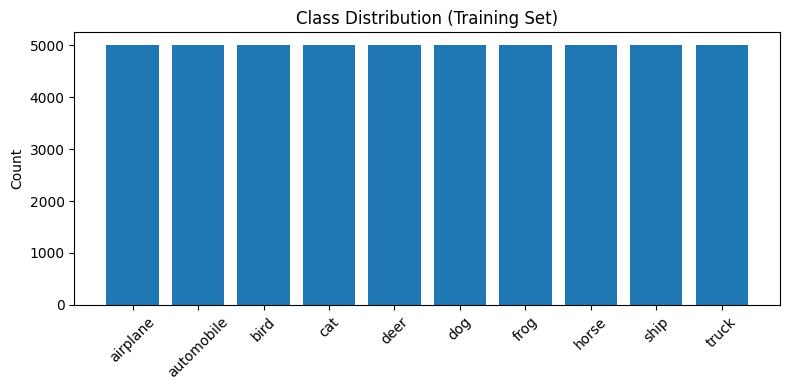

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Display 10 sample images
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()

# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8,4))
plt.bar([class_names[i] for i in unique], counts)
plt.xticks(rotation=45)
plt.title("Class Distribution (Training Set)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Task 2

In [ ]:
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.models import Sequential

X_train_norm = X_train.astype('float32') / 255.0
sample_img = X_train_norm[0:1]  # shape (1, 32, 32, 3)

for k in [3, 5, 7]:
    model = Sequential([Conv2D(8, (k, k), activation='relu', input_shape=(32,32,3))])
    output = model.predict(sample_img, verbose=0)
    print(f"Kernel size {k}x{k} -> Feature map shape: {output.shape}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Kernel size 3x3 -> Feature map shape: (1, 30, 30, 8)
Kernel size 5x5 -> Feature map shape: (1, 28, 28, 8)
Kernel size 7x7 -> Feature map shape: (1, 26, 26, 8)


Task 3

In [ ]:
for stride in [1, 2]:
    for padding in ['same', 'valid']:
        model = Sequential([
            Conv2D(8, (3,3), strides=stride, padding=padding,
                   activation='relu', input_shape=(32,32,3))
        ])
        output = model.predict(sample_img, verbose=0)
        print(f"Stride={stride}, Padding={padding} -> Output shape: {output.shape}")

Stride=1, Padding=same -> Output shape: (1, 32, 32, 8)
Stride=1, Padding=valid -> Output shape: (1, 30, 30, 8)
Stride=2, Padding=same -> Output shape: (1, 16, 16, 8)
Stride=2, Padding=valid -> Output shape: (1, 15, 15, 8)


Task 4

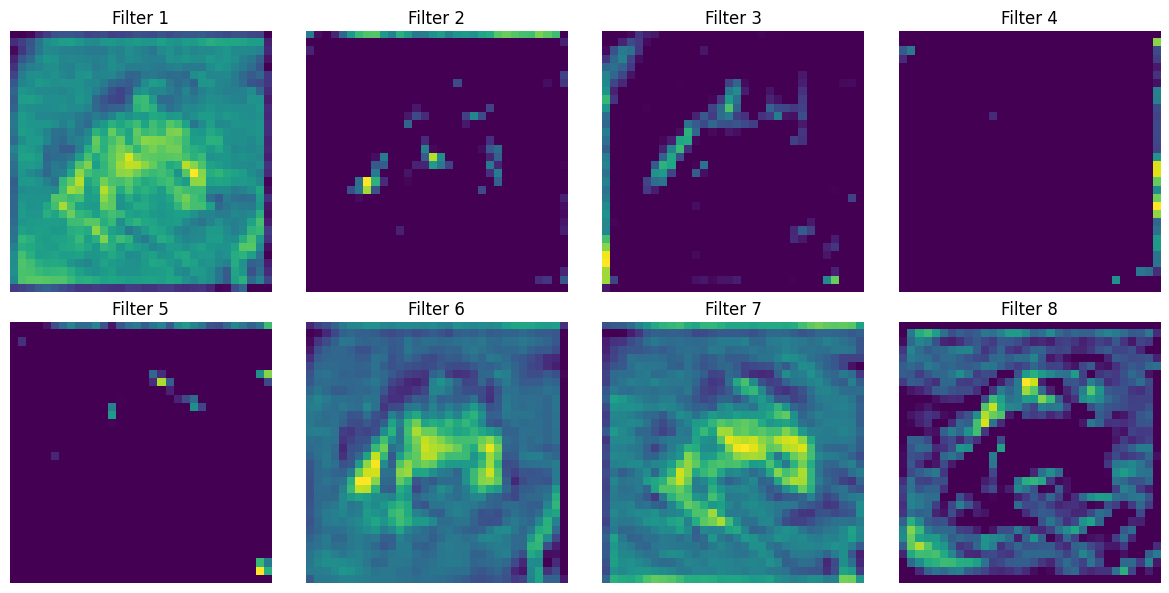

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

inp = Input(shape=(32,32,3))
conv_layer = Conv2D(16, (3,3), activation='relu', padding='same')(inp)
feature_model = Model(inputs=inp, outputs=conv_layer)

feature_maps = feature_model.predict(sample_img, verbose=0)

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='viridis')
    plt.title(f"Filter {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Task 5

In [ ]:
from tensorflow.keras.layers import MaxPooling2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

X_test_norm = X_test.astype('float32') / 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

def build_pooling_model(pooling_type):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        MaxPooling2D((2,2)) if pooling_type == 'max' else AveragePooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)) if pooling_type == 'max' else AveragePooling2D((2,2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

max_model = build_pooling_model('max')
avg_model = build_pooling_model('average')

# Build a small sub-model to inspect the shape after the first pooling layer
from tensorflow.keras.models import Model

max_pool_output = Model(inputs=max_model.inputs, outputs=max_model.layers[1].output)
avg_pool_output = Model(inputs=avg_model.inputs, outputs=avg_model.layers[1].output)

sample_img = X_train_norm[0:1]
print("Max Pooling output shape after first pool:", max_pool_output.predict(sample_img, verbose=0).shape)
print("Average Pooling output shape after first pool:", avg_pool_output.predict(sample_img, verbose=0).shape)

history_max = max_model.fit(X_train_norm, y_train_cat, epochs=5, batch_size=32,
                             validation_split=0.1, verbose=1)
history_avg = avg_model.fit(X_train_norm, y_train_cat, epochs=5, batch_size=32,
                             validation_split=0.1, verbose=1)

print("Max Pooling final val accuracy:", history_max.history['val_accuracy'][-1])
print("Average Pooling final val accuracy:", history_avg.history['val_accuracy'][-1])

Max Pooling output shape after first pool: (1, 16, 16, 32)
Average Pooling output shape after first pool: (1, 16, 16, 32)
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 56ms/step - accuracy: 0.4841 - loss: 1.4425 - val_accuracy: 0.5938 - val_loss: 1.1587
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 55ms/step - accuracy: 0.6263 - loss: 1.0703 - val_accuracy: 0.6578 - val_loss: 0.9896
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 54ms/step - accuracy: 0.6697 - loss: 0.9506 - val_accuracy: 0.6598 - val_loss: 0.9937
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 55ms/step - accuracy: 0.6990 - loss: 0.8674 - val_accuracy: 0.6766 - val_loss: 0.9441
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - accuracy: 0.7213 - loss: 0.7991 - val_accuracy: 0.6942 - val_loss: 0.8942
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 48ms/step - accuracy: 0.4359 - loss: 1.5602 - val_accuracy: 0.5274 - val_loss: 1.3120
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 48ms/step - accuracy: 0.5666 - loss: 1.2236 - v

Task 6

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(X_train_norm, y_train_cat,
                     epochs=20, batch_size=32,
                     validation_data=(X_test_norm, y_test_cat),
                     verbose=1)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 97s 61ms/step - accuracy: 0.5163 - loss: 1.3545 - val_accuracy: 0.6036 - val_loss: 1.1111
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 94s 60ms/step - accuracy: 0.6566 - loss: 0.9814 - val_accuracy: 0.6698 - val_loss: 0.9353
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 59ms/step - accuracy: 0.7053 - loss: 0.8397 - val_accuracy: 0.6904 - val_loss: 0.8868
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 62ms/step - accuracy: 0.7402 - loss: 0.7397 - val_accuracy: 0.6841 - val_loss: 0.9128
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 59ms/step - accuracy: 0.7722 - loss: 0.6479 - val_accuracy: 0.7064 - val_loss: 0.8532
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 61ms/step - accuracy: 0.7993 - loss: 0.5721 - val_accuracy: 0.7081 - val_loss: 0.8771
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 139s 59ms/step - accuracy: 0.8223 - loss: 0.5016 - val_accuracy: 0.7128 - val_loss: 0.9057
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 59ms/step - accuracy: 0.848

Task 7

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step
Test Accuracy: 0.6974
Precision (macro): 0.6983441070499596
Recall (macro): 0.6974
F1-score (macro): 0.6971413097347817


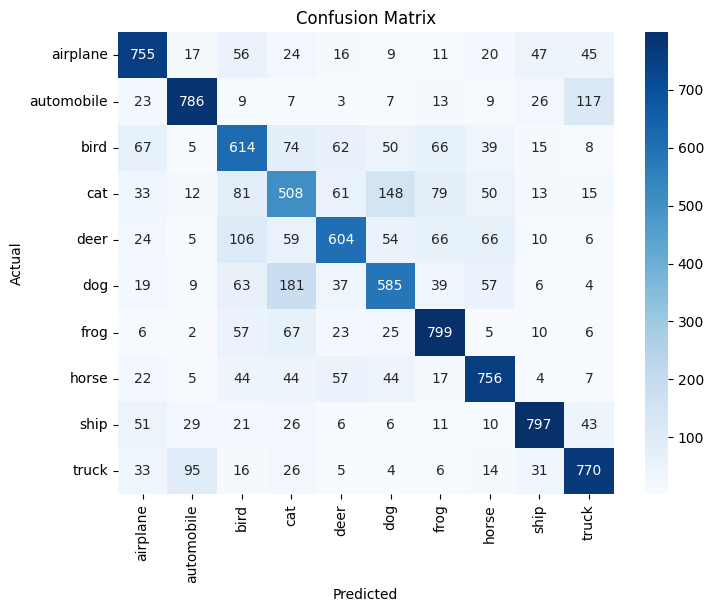

              precision    recall  f1-score   support

    airplane       0.73      0.76      0.74      1000
  automobile       0.81      0.79      0.80      1000
        bird       0.58      0.61      0.59      1000
         cat       0.50      0.51      0.50      1000
        deer       0.69      0.60      0.64      1000
         dog       0.63      0.58      0.61      1000
        frog       0.72      0.80      0.76      1000
       horse       0.74      0.76      0.75      1000
        ship       0.83      0.80      0.81      1000
       truck       0.75      0.77      0.76      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import seaborn as sns

y_pred_probs = model.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("Test Accuracy:", acc)
print("Precision (macro):", prec)
print("Recall (macro):", rec)
print("F1-score (macro):", f1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

Mandatory Plots

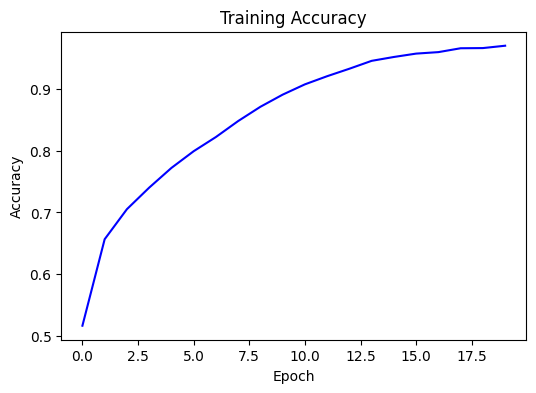

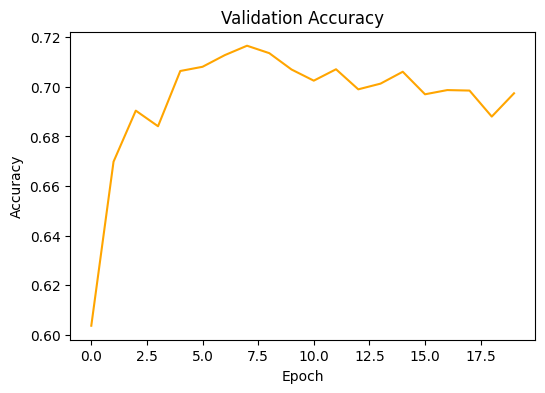

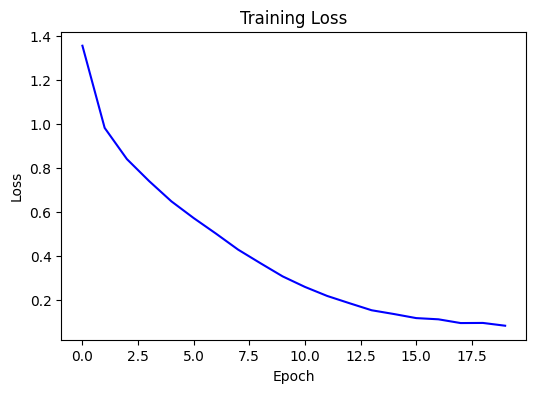

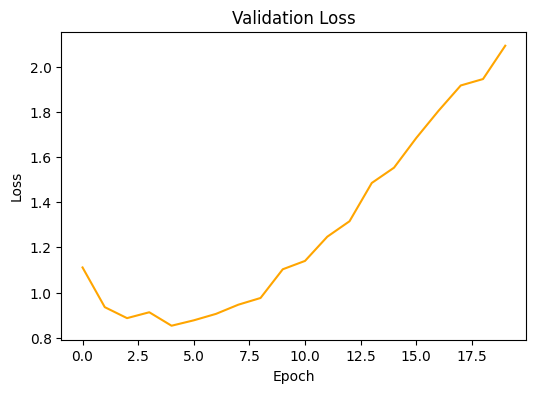

In [ ]:
# Plot 3: Training Accuracy
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], color='blue')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Plot 4: Validation Accuracy
plt.figure(figsize=(6,4))
plt.plot(history.history['val_accuracy'], color='orange')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Plot 5: Training Loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], color='blue')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Plot 6: Validation Loss
plt.figure(figsize=(6,4))
plt.plot(history.history['val_loss'], color='orange')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()